# Assignment 3 – Parte 2: Mapas del Perú

**Grupo 7 · Temporada: enero–mayo de 2024**

## Pregunta

**¿Los departamentos con mayor lluvia acumulada son también los que registran más declaratorias de emergencia durante enero–mayo de 2024?**

En esta parte se representa espacialmente la lluvia acumulada y las declaratorias de emergencia. El cruce se realiza por **ubigeo como texto**, preservando el cero a la izquierda.


In [1]:
from pathlib import Path
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

BASE = Path(".") if Path("datos/dataset.csv").exists() else Path("assignment_3")
RUTA_DATOS = BASE / "datos" / "dataset.csv"
RUTA_GEO = BASE / "datos" / "distritos.geojson"

df = pd.read_csv(RUTA_DATOS, dtype={"ubigeo": "string"})
df["ubigeo"] = df["ubigeo"].str.zfill(2)

print("Dataset:", df.shape)
display(df.head())


Dataset: (25, 9)


,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,01,Amazonas,Chachapoyas,-6.23169,-77.86903,455.0,0,4,2
1,02,Áncash,Huaraz,-9.52614,-77.52869,1058.3,3,5,5
2,03,Apurímac,Abancay,-13.63426,-72.88380,670.6,2,7,4
3,04,Arequipa,Arequipa,-16.39899,-71.53747,235.3,1,7,6
4,05,Ayacucho,Ayacucho,-13.16380,-74.22345,467.5,1,7,5


## 1. Carga de geometrías y construcción del ubigeo departamental

El archivo `distritos.geojson` proviene del material de las sesiones 7/8 del curso. Como contiene geometrías distritales con ubigeos de 6 dígitos, se toma los **dos primeros dígitos** para obtener el código departamental y luego se disuelven las geometrías por departamento.


In [2]:
gdf_dist = gpd.read_file(RUTA_GEO)

gdf_dist["ubigeo"] = gdf_dist["ubigeo"].astype("string").str.zfill(6)
gdf_dist["ubigeo_dep"] = gdf_dist["ubigeo"].str[:2]

gdf_dep = (
    gdf_dist[["ubigeo_dep", "geometry"]]
    .dissolve(by="ubigeo_dep", as_index=False)
)

print("Departamentos con geometría disponible:", len(gdf_dep))
display(gdf_dep.head())


Departamentos con geometría disponible: 21


,ubigeo_dep,geometry
0,01,"MULTIPOLYGON (((-78.55741 -6.07141, -78.56059 ..."
1,02,"MULTIPOLYGON (((-77.84372 -9.84405, -77.82694 ..."
2,05,"MULTIPOLYGON (((-74.21165 -14.29128, -74.18575..."
3,06,"MULTIPOLYGON (((-78.95451 -7.19027, -78.9437 -..."
4,07,"POLYGON ((-77.10971 -11.97616, -77.11805 -11.9..."


## 2. Cruce por ubigeo y reporte de no cruces

Se compara el ubigeo departamental del dataset con los códigos disponibles en el GeoJSON. **No se fuerzan coincidencias ni se inventan geometrías**: cualquier departamento ausente se reporta explícitamente.


In [3]:
codigos_geo = set(gdf_dep["ubigeo_dep"].astype(str))
codigos_datos = set(df["ubigeo"].astype(str))

sin_geometria = (
    df.loc[~df["ubigeo"].isin(codigos_geo), ["ubigeo", "departamento"]]
    .sort_values("ubigeo")
    .reset_index(drop=True)
)

sin_datos = sorted(codigos_geo - codigos_datos)

print(f"Ubigeos en dataset: {len(codigos_datos)}")
print(f"Ubigeos con geometría: {len(codigos_geo)}")
print(f"Departamentos del dataset sin geometría: {len(sin_geometria)}")
display(sin_geometria)

print("Ubigeos con geometría pero sin datos:", sin_datos)

gdf_map = gdf_dep.merge(
    df,
    left_on="ubigeo_dep",
    right_on="ubigeo",
    how="inner",
    validate="one_to_one"
)

print("Cruces correctos:", len(gdf_map))


Ubigeos en dataset: 25
Ubigeos con geometría: 21
Departamentos del dataset sin geometría: 4


,ubigeo,departamento
0,03,Apurímac
1,04,Arequipa
2,09,Huancavelica
3,23,Tacna


Ubigeos con geometría pero sin datos: []
Cruces correctos: 21


## 3. Coropleta estática por cuantiles – lluvia acumulada

La clasificación por cuantiles distribuye los departamentos en grupos según su posición relativa en la variable, facilitando la comparación territorial.


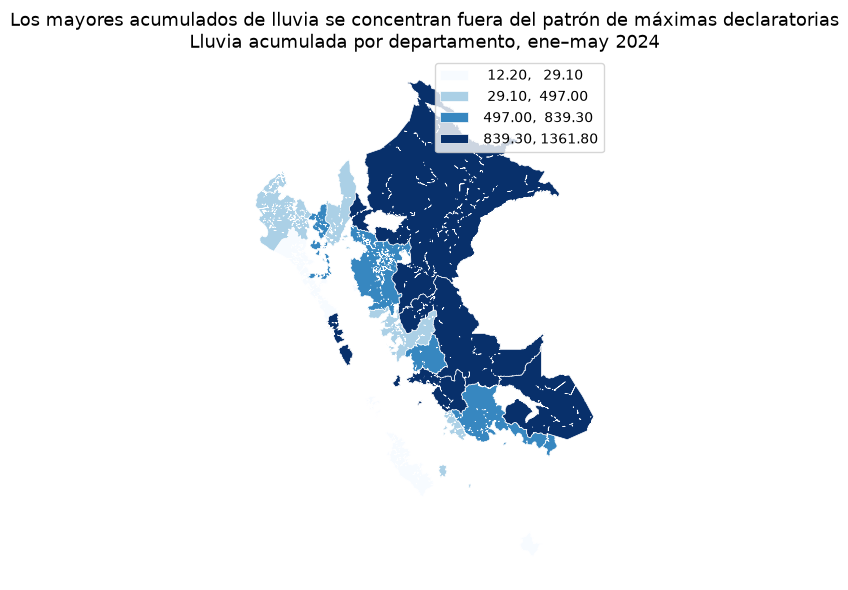

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

gdf_map.plot(
    column="lluvia_total_mm",
    scheme="Quantiles",
    k=4,
    cmap="Blues",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title(
    "Los mayores acumulados de lluvia se concentran fuera del patrón de máximas declaratorias\n"
    "Lluvia acumulada por departamento, ene–may 2024",
    fontsize=13
)
ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Coropleta estática por cuantiles – declaratorias

El segundo mapa permite contrastar directamente la distribución espacial de declaratorias con la distribución observada de lluvia.


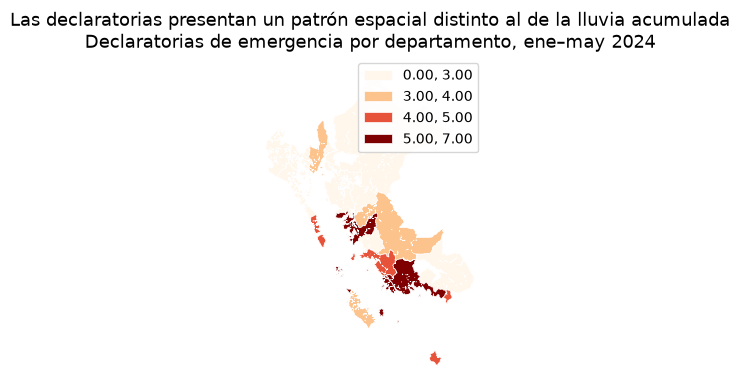

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))

gdf_map.plot(
    column="declaratorias",
    scheme="Quantiles",
    k=4,
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title(
    "Las declaratorias presentan un patrón espacial distinto al de la lluvia acumulada\n"
    "Declaratorias de emergencia por departamento, ene–may 2024",
    fontsize=13
)
ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Mapa interactivo con Folium

Se construye un mapa coroplético de lluvia acumulada. Al pasar el cursor se muestran el departamento, la lluvia acumulada y el número de declaratorias.

> Para evitar que el notebook pese varios MB, el mapa Folium **no se incrusta como output**. Se genera al ejecutar esta celda y se guarda como `mapa_interactivo.html`.


In [6]:
geojson_map = json.loads(gdf_map.to_json())

m = folium.Map(
    location=[-9.2, -75.0],
    zoom_start=5,
    tiles="CartoDB positron"
)

folium.Choropleth(
    geo_data=geojson_map,
    data=gdf_map,
    columns=["ubigeo_dep", "lluvia_total_mm"],
    key_on="feature.properties.ubigeo_dep",
    fill_color="YlGnBu",
    fill_opacity=0.75,
    line_opacity=0.35,
    legend_name="Lluvia acumulada (mm)"
).add_to(m)

folium.GeoJson(
    geojson_map,
    style_function=lambda feature: {
        "fillColor": "transparent",
        "color": "#444444",
        "weight": 0.4,
        "fillOpacity": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["departamento", "lluvia_total_mm", "declaratorias"],
        aliases=["Departamento:", "Lluvia acumulada (mm):", "Declaratorias:"],
        localize=True,
        sticky=False
    )
).add_to(m)

salida_mapa = BASE / "mapa_interactivo.html"
m.save(salida_mapa)

print("Mapa Folium generado correctamente.")
print("Archivo:", salida_mapa)


Mapa Folium generado correctamente.
Archivo: mapa_interactivo.html


## Interpretación geográfica

Los mapas refuerzan lo observado en los gráficos de la Parte 1: **los departamentos con mayor lluvia acumulada no coinciden necesariamente con los que registran el mayor número de declaratorias**. La distribución espacial de ambas variables es distinta, por lo que la lluvia acumulada por sí sola no explica el patrón de declaratorias durante la temporada analizada.

**Mapa vs. gráficos.** Los gráficos permiten comparar con mayor precisión magnitudes y relaciones entre variables; el mapa añade contexto espacial y permite reconocer agrupamientos o contrastes territoriales que no son tan evidentes en una tabla o un gráfico cartesiano.

**Limitación cartográfica.** El GeoJSON facilitado en las sesiones 7/8 no contiene geometrías para todos los departamentos presentes en el dataset. Por ello, el notebook reporta los no cruces y solo representa los departamentos con geometría disponible, sin asignar formas de manera artificial.
